# Section 3: Corner Detection

In [103]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter,maximum_filter
%matplotlib inline

In [104]:
oswald=cv2.imread('oswald.png')
if oswald is None:
    raise FileNotFoundError("oswald.png not found. Please ensure it's in the working directory.")
oswald_gray=cv2.cvtColor(oswald,cv2.COLOR_BGR2GRAY).astype(np.float64)/255.0
oswald_color=cv2.cvtColor(oswald,cv2.COLOR_BGR2RGB)

## Task 1: Heuristic Corner Detection via Edge Intersection

We approximate corners as points where both horizontal and vertical gradient magnitudes are high.

### 1. Compute gradients using Sobel operators

In [105]:
Ix=cv2.Sobel(oswald_gray,cv2.CV_64F,1,0,ksize=3)
Iy=cv2.Sobel(oswald_gray,cv2.CV_64F,0,1,ksize=3)
Ix_mag=np.abs(Ix)
Iy_mag=np.abs(Iy)
Ix_norm=Ix_mag/Ix_mag.max()
Iy_norm=Iy_mag/Iy_mag.max()

### 2. Display horizontal and vertical gradient magnitude maps

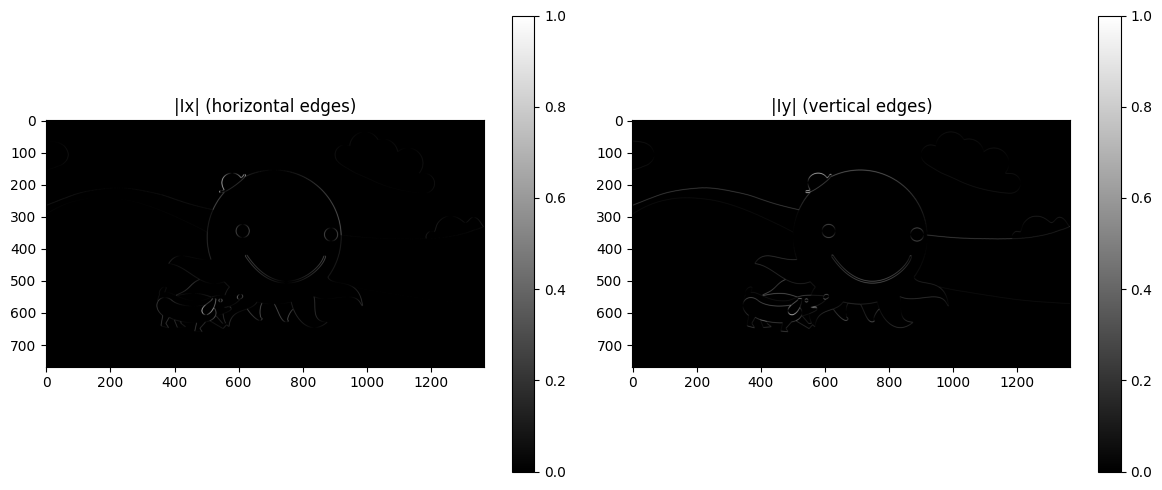

In [106]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(Ix_norm,cmap='gray')
plt.title('|Ix| (horizontal edges)')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(Iy_norm,cmap='gray')
plt.title('|Iy| (vertical edges)')
plt.colorbar()
plt.tight_layout()
plt.show()

### 3. Generate corner maps for thresholds 0.7, 0.8, 0.9
We consider a pixel a "heuristic corner" if both normalized gradient magnitudes exceed the threshold.

In [107]:
thresholds=[0.7,0.8,0.9]
corner_maps=[]
for thresh in thresholds:
    corner=(Ix_norm>thresh)&(Iy_norm>thresh)
    corner_maps.append(corner)

### 4. Overlay detected corners on the original image
We'll create a figure with three subplots, each showing the original image with corners marked in red.

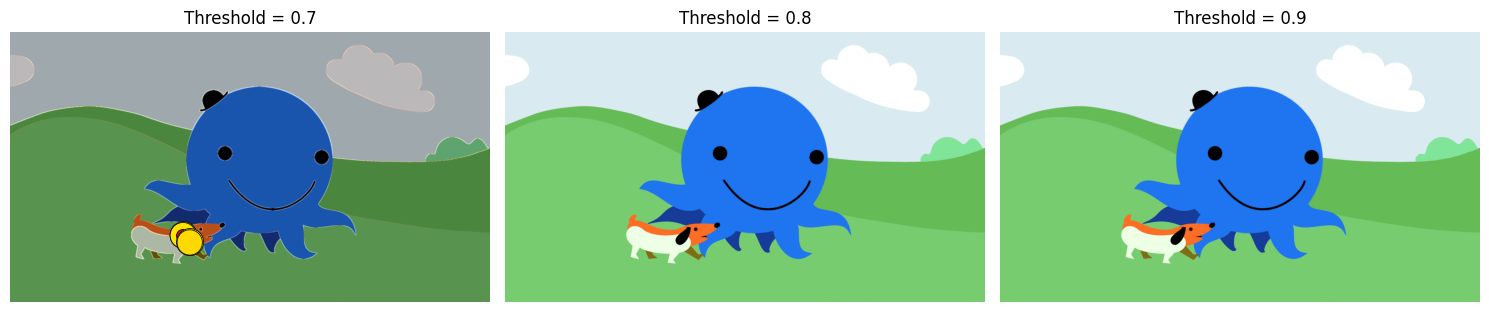

In [116]:
plt.figure(figsize=(15,4))
for i,thresh in enumerate(thresholds):
    plt.subplot(1,3,i+1)
    corner_strength = Ix_norm * Iy_norm
    ys, xs = np.where(corner_maps[i])
    plt.imshow(oswald_color)
    if ys.size:
        strengths = corner_strength[ys, xs]
        norm = (strengths - strengths.min()) / (strengths.max() - strengths.min() + 1e-12)
        sizes = np.clip(norm * 300 + 80, 80, 2000)
        colors = plt.cm.autumn(norm)
        vmax = np.percentile(corner_strength, 99)
        plt.imshow(corner_strength, cmap='hot', alpha=0.28, vmin=0, vmax=vmax)
        plt.scatter(xs, ys, s=sizes, c=colors, edgecolors='black', linewidths=0.6, alpha=0.95)
    plt.title(f'Threshold = {thresh}')
    plt.axis('off')
plt.tight_layout()
plt.show()

### Observation:
 Lower thresholds (0.7) produce some corners (including some along edges), and higher thresholds (0.8and 0.9) have not given any corners at all

## Task 2: Harris Corner Detection

### 1. Compute gradients and their products

In [109]:
Ixx=Ix*Ix
Iyy=Iy*Iy
Ixy=Ix*Iy

### 2. Apply Gaussian smoothing (σ = 0.4, kernel size = 3)
We use `scipy.ndimage.gaussian_filter` with `sigma=0.4` and a truncation that yields approximately a 3x3 kernel. The function automatically determines the kernel size based on sigma, but we can enforce a window by passing a `truncate` value. For a 3x3 kernel with sigma=0.4, we want the filter to include only up to 1 pixel away, so `truncate = 1.0 / sigma` ≈ 2.5, but that would give a larger kernel. Simpler: we can use cv2.GaussianBlur with `ksize=(3,3)`, `sigmaX=0.4`. Both are allowed. We'll use `cv2.GaussianBlur` to exactly control kernel size.

In [117]:
ksize=(3,3)
sigma=0.4
Ixx_smooth=cv2.GaussianBlur(Ixx,ksize,sigmaX=sigma)
Iyy_smooth=cv2.GaussianBlur(Iyy,ksize,sigmaX=sigma)
Ixy_smooth=cv2.GaussianBlur(Ixy,ksize,sigmaX=sigma)

### 3. Compute Harris response R for k = 0.04, 0.05, 0.06
Formula: `R = det(M) - k * trace(M)^2`, where:

`det = Ixx_smooth * Iyy_smooth - Ixy_smooth^2`

`trace = Ixx_smooth + Iyy_smooth`

In [149]:
k_values=[0.04,0.05,0.06]
R_maps=[]
det=Ixx_smooth*Iyy_smooth-Ixy_smooth**2
trace=Ixx_smooth+Iyy_smooth
for k in k_values:
    R=det-k*trace**2
    R_maps.append(R)

### 4. Non‑maximum suppression and corner detection
We  can find the local maxim in a 3×3 neighborhood and then apply a threshold to keep only strong corners. I chose the threshold as a fraction of the maximum.

In [150]:
def get_corners(R,threshold_ratio=0.01,neighborhood_size=3):
    local_max=maximum_filter(R,size=neighborhood_size)==R
    threshold=threshold_ratio*R.max()
    corners=local_max&(R>threshold)
    return corners

corners_list=[]
threshold_ratio=0.01
for R in R_maps:
    corners=get_corners(R,threshold_ratio)
    corners_list.append(corners)

### 5. Display Harris response heatmaps and corner overlays

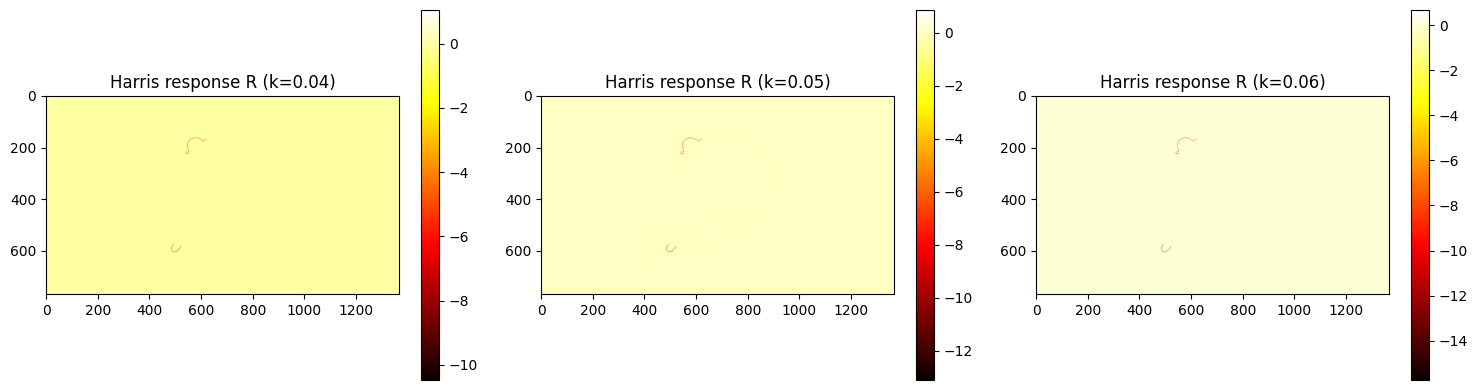

In [151]:
plt.figure(figsize=(15, 4))
for i, (k, R) in enumerate(zip(k_values, R_maps)):
    plt.subplot(1, 3, i+1)
    plt.imshow(R, cmap='hot')
    plt.colorbar()
    plt.title(f'Harris response R (k={k})')
plt.tight_layout()
plt.show()

Not quite visible due to the subtlety of the responses

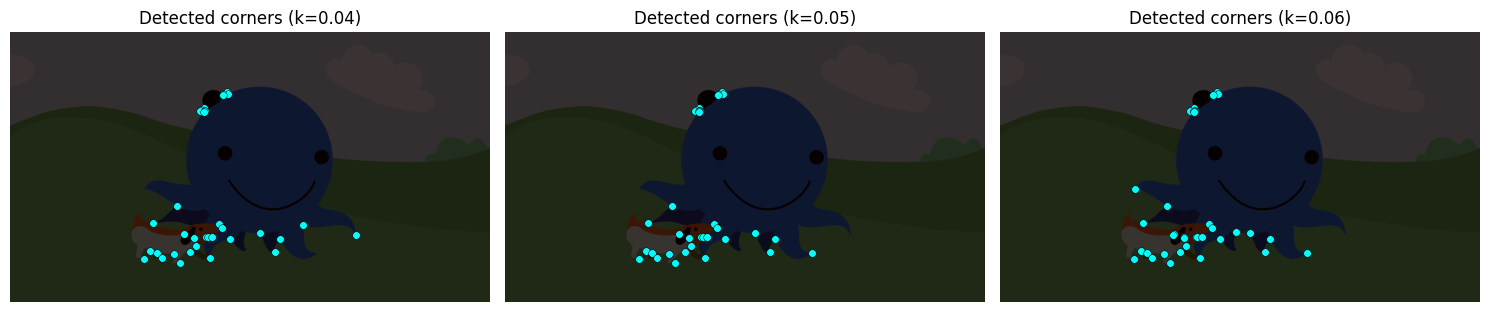

In [152]:
plt.figure(figsize=(15,4))
for i,(k,corners,R) in enumerate(zip(k_values,corners_list,R_maps)):
    plt.subplot(1,3,i+1)
    Rpos = np.copy(R)
    Rpos[Rpos < 0] = 0
    if np.any(Rpos > 0):
        vmax = np.percentile(Rpos[Rpos > 0], 99)
    else:
        vmax = Rpos.max() if Rpos.size else 1.0
    vmax = max(vmax, 1e-8)
    plt.imshow(oswald_color)
    plt.imshow(Rpos, cmap='hot', vmin=0, vmax=vmax, alpha=0.8)
    ys, xs = np.where(corners)
    plt.scatter(xs, ys, s=30, c='cyan', edgecolors='black', linewidths=0.4)
    plt.title(f'Detected corners (k={k})')
    plt.axis('off')
plt.tight_layout()
plt.show()


### 6. Explanation of parameter influence
Influence of k:
The parameter k in the Harris response formula R = det(M) - k·trace(M)² controls the sensitivity to corners versus edges.

A smaller k makes the detector more sensitive, i.e., it responds to both strong corners and some edge points.

A larger k suppresses edge responses, keeping only the strongest corner-like structures.

In our results, the edges are almost identical in three of the cases

Influence of Gaussian window size (σ):
The Gaussian smoothing applied to Ixx, Iyy, and Ixy defines the neighborhood over which gradients are accumulated.

A smaller σ makes the detector sensitive to fine details and local variations, but also to noise.

A larger σ smooths more, producing a more global estimate of the structure tensor, which can merge nearby corners and reduce noise but may miss small-scale corners.

In this assignment we have used σ=0.4 with a 3×3 kernel, which is quite local. For a noisier image or larger structures, increasing σ might improve robustness.

